In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/population-data-usa/population_usa_forecast.csv
/kaggle/input/population-data-usa/usa_city_population.csv
/kaggle/input/population-data-usa/population_usa.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../input/population-data-usa/population_usa.csv")

In [4]:
df.head()

,Year,Population,Yearly % Change,Yearly Change,Migrants (net),Median Age,Fertility Rate,Density (P/Km²),Urban Pop %,Urban Population,Country's Share of World Pop,World Population,U.S. Global Rank
0,2020,331002651,0.59,1937734,954806,38.3,1.78,36,82.8,273975139,4.25,7794798739,3
1,2019,329064917,0.60,1968652,954806,37.7,1.85,36,82.5,271365914,4.27,7713468100,3
2,2018,327096265,0.62,2011509,954806,37.7,1.85,36,82.2,268786714,4.29,7631091040,3
3,2017,325084756,0.64,2068761,954806,37.7,1.85,36,81.9,266243516,4.31,7547858925,3
4,2016,323015995,0.67,2137685,954806,37.7,1.85,35,81.7,263743312,4.33,7464022049,3


In [5]:
df.shape

(18, 13)

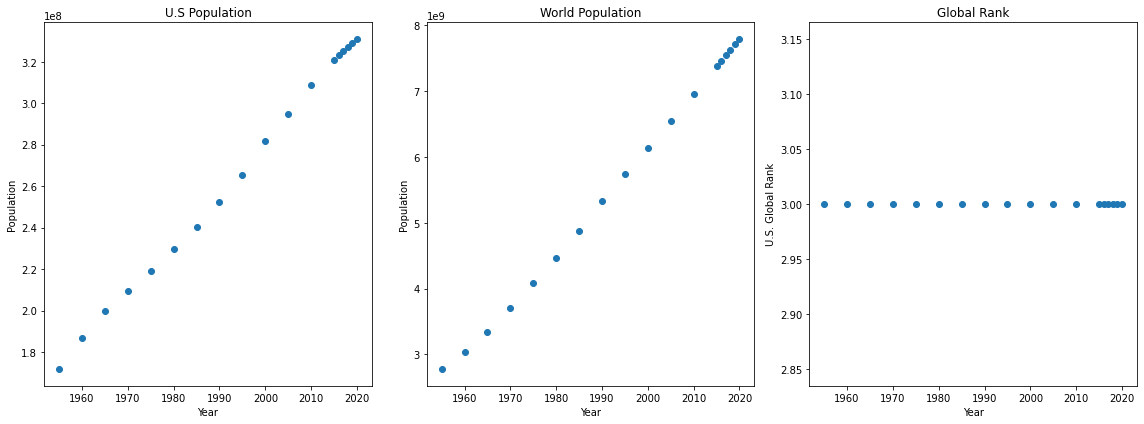

In [6]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['Year'],df['Population'],'o')
axes[0].set_ylabel("Population")
axes[0].set_xlabel("Year")
axes[0].set_title("U.S Population")

axes[1].plot(df['Year'],df['World Population'],'o')
axes[1].set_ylabel("Population")
axes[1].set_xlabel("Year")
axes[1].set_title("World Population")

axes[2].plot(df['Year'],df['U.S. Global Rank'],'o')
axes[2].set_ylabel("U.S. Global Rank")
axes[2].set_xlabel("Year")
axes[2].set_title("Global Rank")
plt.tight_layout();

In [7]:
X = df.drop('Population',axis = 1)
y = df['Population']

In [8]:
X.head()

,Year,Yearly % Change,Yearly Change,Migrants (net),Median Age,Fertility Rate,Density (P/Km²),Urban Pop %,Urban Population,Country's Share of World Pop,World Population,U.S. Global Rank
0,2020,0.59,1937734,954806,38.3,1.78,36,82.8,273975139,4.25,7794798739,3
1,2019,0.60,1968652,954806,37.7,1.85,36,82.5,271365914,4.27,7713468100,3
2,2018,0.62,2011509,954806,37.7,1.85,36,82.2,268786714,4.29,7631091040,3
3,2017,0.64,2068761,954806,37.7,1.85,36,81.9,266243516,4.31,7547858925,3
4,2016,0.67,2137685,954806,37.7,1.85,35,81.7,263743312,4.33,7464022049,3


In [9]:
y.head()

0    331002651
1    329064917
2    327096265
3    325084756
4    323015995
Name: Population, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [12]:
X_train

,Year,Yearly % Change,Yearly Change,Migrants (net),Median Age,Fertility Rate,Density (P/Km²),Urban Pop %,Urban Population,Country's Share of World Pop,World Population,U.S. Global Rank
12,1980,0.93,2079021,754176,30.0,1.77,25,73.8,169422683,5.15,4458003514,3
5,2015,0.76,2373367,992343,37.6,1.88,35,81.4,261287811,4.35,7379797139,3
10,1990,0.95,2324097,673371,32.8,1.91,28,75.4,190156233,4.73,5327231061,3
4,2016,0.67,2137685,954806,37.7,1.85,35,81.7,263743312,4.33,7464022049,3
8,2000,1.22,3309433,1771991,35.2,2.00,31,79.1,222927913,4.59,6143493823,3
9,1995,1.01,2608687,892751,34.0,2.03,29,77.4,205240402,4.62,5744212979,3
17,1955,1.57,2576188,173553,30.3,3.31,19,67.2,115375863,6.19,2773019936,3
13,1975,0.90,1913582,577869,29.0,2.03,24,73.7,161450209,5.37,4079480606,3
7,2005,0.93,2656520,1066979,36.1,2.04,32,80.0,235892407,4.51,6541907027,3
15,1965,1.36,2602621,367146,28.6,3.23,22,71.9,143624659,5.98,3339583597,3


In [13]:
y_train

12    229476354
5     320878310
10    252120309
4     323015995
8     281710909
9     265163745
17    171685336
13    219081251
7     294993511
15    199733676
6     309011475
11    240499825
Name: Population, dtype: int64

In [14]:
X_test

,Year,Yearly % Change,Yearly Change,Migrants (net),Median Age,Fertility Rate,Density (P/Km²),Urban Pop %,Urban Population,Country's Share of World Pop,World Population,U.S. Global Rank
3,2017,0.64,2068761,954806,37.7,1.85,36,81.9,266243516,4.31,7547858925,3
14,1970,0.96,1955933,311211,28.4,2.54,23,73.6,154262109,5.66,3700437046,3
1,2019,0.60,1968652,954806,37.7,1.85,36,82.5,271365914,4.27,7713468100,3
2,2018,0.62,2011509,954806,37.7,1.85,36,82.2,268786714,4.29,7631091040,3
0,2020,0.59,1937734,954806,38.3,1.78,36,82.8,273975139,4.25,7794798739,3
16,1960,1.69,3007047,424979,29.7,3.58,20,70.0,130757407,6.15,3034949748,3


In [15]:
y_test

3     325084756
14    209513341
1     329064917
2     327096265
0     331002651
16    186720571
Name: Population, dtype: int64

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
model = LinearRegression()

In [18]:
model.fit(X_train,y_train)

LinearRegression()

In [19]:
test_predictions = model.predict(X_test)

In [20]:
test_predictions

array([3.11382355e+08, 1.94645196e+08, 3.39681021e+08, 3.25809493e+08,
       3.15343430e+08, 2.05181918e+08])

In [21]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [22]:
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)

In [23]:
MAE

12432331.519119263

In [24]:
MSE

184867913462221.62

In [25]:
RMSE

13596614.04402661

In [26]:
df['Population'].mean()

267547399.83333334

In [27]:
test_predictions = model.predict(X_test)
test_res = y_test - test_predictions

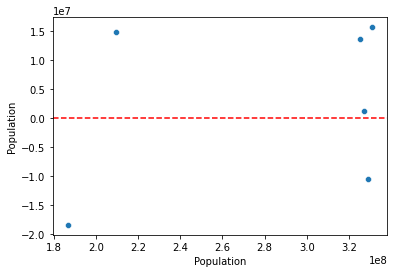

In [28]:
sns.scatterplot(x=y_test,y=test_res)
plt.axhline(y=0, color='r', linestyle='--')

In [29]:
len(test_res)

6

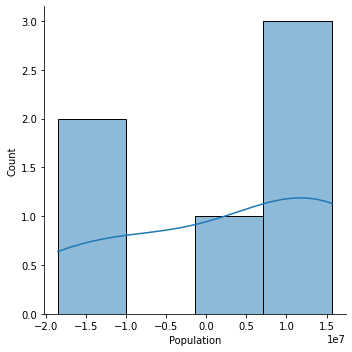

In [30]:
sns.displot(test_res,kde=True)

In [31]:
final_model = LinearRegression()

In [32]:
final_model.fit(X,y)

LinearRegression()

In [33]:
y_hat = final_model.predict(X)

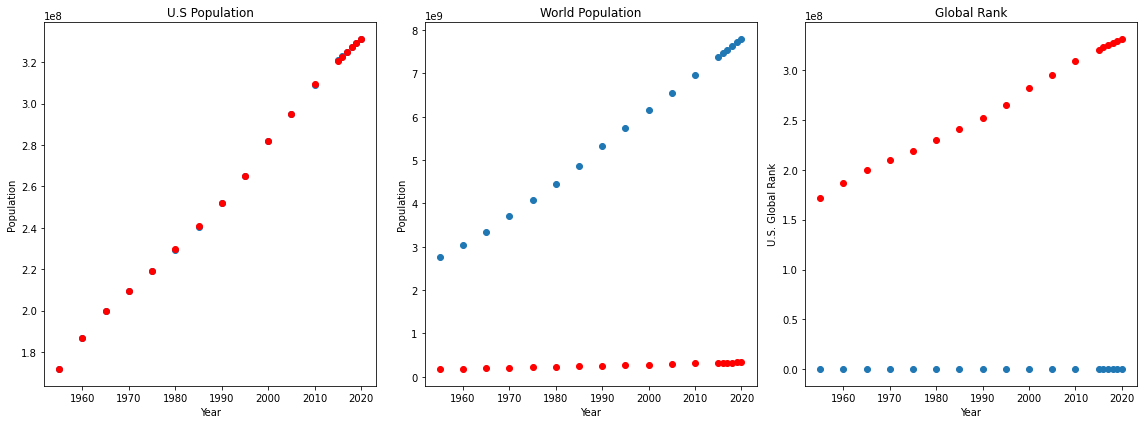

In [34]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['Year'],df['Population'],'o')
axes[0].plot(df['Year'],y_hat,'o',color='red')
axes[0].set_ylabel("Population")
axes[0].set_xlabel("Year")
axes[0].set_title("U.S Population")

axes[1].plot(df['Year'],df['World Population'],'o')
axes[1].plot(df['Year'],y_hat,'o',color='red')
axes[1].set_ylabel("Population")
axes[1].set_xlabel("Year")
axes[1].set_title("World Population")

axes[2].plot(df['Year'],df['U.S. Global Rank'],'o')
axes[2].plot(df['Year'],y_hat,'o',color='red')
axes[2].set_ylabel("U.S. Global Rank")
axes[2].set_xlabel("Year")
axes[2].set_title("Global Rank")
plt.tight_layout();

In [35]:
residuals = y_hat - y

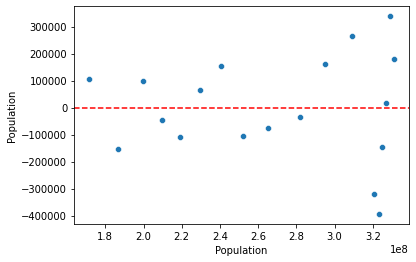

In [36]:
sns.scatterplot(x=y,y=residuals)
plt.axhline(y=0, color='r', linestyle='--')

In [37]:
final_model.coef_

array([ 1.83471073e+06, -1.13799949e+07,  2.63050817e+00,  2.03960726e+00,
       -3.38964181e+04,  6.86344384e+06, -2.44130406e+05, -3.81151800e+06,
        1.39483449e+00, -1.55053237e+07, -2.94420835e-02,  0.00000000e+00])

In [38]:
coeff_df = pd.DataFrame(final_model.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Year,1.834711e+06
Yearly % Change,-1.137999e+07
Yearly Change,2.630508e+00
Migrants (net),2.039607e+00
Median Age,-3.389642e+04
Fertility Rate,6.863444e+06
Density (P/Km²),-2.441304e+05
Urban Pop %,-3.811518e+06
Urban Population,1.394834e+00
Country's Share of World Pop,-1.550532e+07


In [39]:
campaign = [[2100,0.37,1000000,954806,40,1.75,36,84.8,300000000,4.2,7794798739,4]]

In [40]:
final_model.predict(campaign)

/opt/conda/lib/python3.7/site-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


array([5.07183884e+08])

In [41]:
from joblib import dump, load

In [42]:
dump(final_model, 'sales_model.joblib') 

['sales_model.joblib']

In [43]:
loaded_model = load('sales_model.joblib')

In [44]:
loaded_model.predict(campaign)

/opt/conda/lib/python3.7/site-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"


array([5.07183884e+08])